In [1]:
%load_ext autoreload
%autoreload 2
import cv2
import h5py
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from dataclasses import dataclass, field
from typing import Optional
from scipy.spatial.distance import mahalanobis
from PIL import Image, ImageDraw
from MirrorFeatureExtractor.mirror_feature_extractor import (
    extract_glcm_features,
    extract_lbp_features,
    extract_edge_features,
    extract_features_for_mirror
)

from baseline import VectorBaseline, build_vector_baseline, distance_mahalanobis, distance_euclidean, distance_cosine

from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor

from DetectionMetrics.detection_metrics import DetectionMetrics, compute_metrics

from baseline import visualization_mirrors

In [6]:
N_MIRRORS, N_FEATURES = 249, 11

# Feature keys in guaranteed order
GLCM_KEYS = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
    'glcm_energy', 'glcm_correlation',
]

LBP_KEYS = ['lbp_entropy', 'lbp_uniformity']
EDGE_KEYS = ['sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']

def extract_all_mirrors(img_gray, mirror_extractor) -> np.ndarray:
    """Ekstrakcja features dla wszystkich luster z jednego obrazu."""
    out = np.full((N_MIRRORS, N_FEATURES), np.nan)
    for i in range(N_MIRRORS):
        out[i, :] = extract_features_for_mirror(img_gray, mirror_extractor, i)
    return out

def extract_features_for_mirror(
        img_gray: np.ndarray,
        mirror_extractor: SimpleMirrorExtractor,
        mirror_id: int,
) -> np.ndarray | None:
    """Extract all featues for a single mirror crop. Return None on failure."""
    try:
        crop = mirror_extractor.extract_mirror_gray(img_gray, mirror_id=mirror_id)
        glcm = extract_glcm_features(crop)
        lbp = extract_lbp_features(crop)
        edge = extract_edge_features(crop)

        vec = np.array(
            [glcm[k] for k in GLCM_KEYS]
            + [lbp[k] for k in LBP_KEYS]
            + [edge[k] for k in EDGE_KEYS],
            dtype=np.float32
        )
        return vec
    except Exception as e:
        print("Mirror %d extrraction failed: %s", mirror_id, e)
        return None


In [5]:
def get_features_array(path_to_h5_baseline_file):
    with h5py.File(path_to_h5_baseline_file, "r") as f:
        features = f["feature_matrix"][:]        # (n_images, 249, 11)
    return features


In [7]:
# Mapowanie nazwa -> indeks
GLCM_KEYS = ['glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
             'glcm_energy', 'glcm_correlation']
LBP_KEYS = ['lbp_entropy', 'lbp_uniformity']
EDGE_KEYS = ['sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']
ALL_FEATURE_KEYS = GLCM_KEYS + LBP_KEYS + EDGE_KEYS
N_FEATURES = len(ALL_FEATURE_KEYS)

FEATURE_IDX = {k: i for i, k in enumerate(ALL_FEATURE_KEYS)}

In [8]:
BASELINE_FILE_UBUNTU = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/baseline/baseline_webcam_features.h5"
BASELINE_FILE_WSL = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/baseline/baseline_webcam_features.h5"
BASELINE_FILE_WSL_2 = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/baseline/baseline_features.h5"

features = get_features_array(BASELINE_FILE_UBUNTU)
baseline = build_vector_baseline(features)

In [11]:
img_path = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/webcam_useful_image/webcam_useful_images/image_2024-05-06_1100.jpg"
img_path_2 = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/2026/05/07/IRCamM1T_20260507_124652.jpg"

img_path_3 = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images/image_2024-05-07_1100.jpg"
# img_path_3 = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images/image_2024-05-04_1700.jpg"
img_path_3 = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images/image_2024-05-04_1700.jpg"
img_path_4 = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2023-04-23_1400.jpg"

img = cv2.imread(str(img_path_3))
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#mirror_extractor = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/calibration/points_WebCam.json")
#mirror_extractor = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/points_IRCam.json")
mirror_extractor = SimpleMirrorExtractor("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/points_WebCam.json")

In [12]:
# 2. Ekstrakcja z nowego obrazu
new_features = extract_all_mirrors(img_gray, mirror_extractor)  # (249, 11)

In [13]:
# 3. Liczymy odległość — score per lustro
scores_maha = distance_mahalanobis(new_features, baseline)
scores_eucl = distance_euclidean(new_features, baseline)
scores_cos = distance_cosine(new_features, baseline)

In [14]:
# 5. Top-N podejrzanych
top10 = np.argsort(-scores_maha)[:10]
print(f"Top 10 podejrzanych: {top10}")

Top 10 podejrzanych: [ 65 243  84  67 172 134  49 173 210 102]


In [27]:
threshold = np.mean(scores_maha) + 3*np.std(scores_maha)
print(threshold)
top = np.where(scores_maha > threshold)[0]
print(top)

6.280153034609365
[ 65  84 243]


In [28]:
scores_maha[top]

array([7.28953378, 6.45985006, 6.52276287])

In [19]:
ground_truth = [152, 176, 189, 190, 191, 192, 193, 209]
ground_truth =[119, 121, 135, 152, 176, 178, 179, 189, 190, 191, 192, 193, 209]
ground_truth = [
    119,
    134,
    135,
    136,
    152,
    153,
    170,
    171,
    176,
    179,
    188,
    190,
    193,
    205,
    209,
    219,
    220,
    232,
    242
  ]
print(len(ground_truth))
pred = top
m1 = compute_metrics(pred, ground_truth)
print(f"Result:        {m1.summary}")

19
Result:        P=0.000 R=0.000 F1=0.000 IoU=0.000 (TP=0, FP=5, FN=19)


In [35]:
baseline.median[50, 0]

np.float32(3350.058)

In [38]:
baseline.std[50, 0]

np.float32(1180.278)

In [37]:
new_features[50, 0] 

np.float64(2441.894775390625)

In [43]:
threshold_low = baseline.median[50, 0] - 2.5*baseline.std[50, 0]
threshold_high = baseline.median[50, 0] + 2.5*baseline.std[50, 0]
print(threshold_low)
print(threshold_high)

399.36328
6300.753


In [49]:
for m_id in range(249):
    threshold_low = baseline.median[m_id, 0] - 1.5*baseline.std[m_id, 0]
    threshold_high = baseline.median[m_id, 0] + 1.5*baseline.std[m_id, 0]
    value = new_features[m_id, 0]
    if value < threshold_low or value > threshold_high:
        print(m_id)

33
47
58
75
92
95
97
114
115
125
130
147
148
201
211
224
241
242
243
245
248


In [57]:
threshold_low = baseline.median[:, 0] - 1.5*baseline.std[:, 0]
threshold_high = baseline.median[:, 0] + 1.5*baseline.std[:, 0]
value_array = new_features[:, 0]
anomaly_index = np.where((value_array < threshold_low) | (value_array > threshold_high))
print(anomaly_index)

(array([ 33,  47,  58,  75,  92,  95,  97, 114, 115, 125, 130, 147, 148,
       201, 211, 224, 241, 242, 243, 245, 248]),)


In [58]:
threshold_low = baseline.median[:, 1] - 1.5*baseline.std[:, 1]
threshold_high = baseline.median[:, 1] + 1.5*baseline.std[:, 1]
value_array = new_features[:, 1]
anomaly_index = np.where((value_array < threshold_low) | (value_array > threshold_high))
print(anomaly_index)

(array([ 33,  47,  58,  64,  75,  97, 102, 114, 115, 130, 147, 155, 156,
       201, 204, 211, 216, 224, 230, 239, 241, 242, 245, 247]),)


In [20]:
def mark_mirrors_on_img(img_path, points_list):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_rgb)

    for points in points_list:
        # === Polygon na podstawie 4 współrzędnych ===
        polygon = patches.Polygon(
                points,
                closed=True,
                linewidth=2,
                edgecolor='red',
                facecolor='red',
                alpha=0.3  # przezroczystość wypełnienia
            )
        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

def mark_mirrors_on_img(img_path, points_list, color):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.imshow(img_rgb)

    for points in points_list:
        # === Polygon na podstawie 4 współrzędnych ===
        polygon = patches.Polygon(
                points,
                closed=True,
                linewidth=2,
                edgecolor=color,
                facecolor=color,
                alpha=0.3  # przezroczystość wypełnienia
            )
        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

In [21]:
outliers = top
p_list = []
for m_id in outliers:
    p_list.append(mirror_extractor.get_point_coords(m_id))

ground_truth_list = []
for m_id in ground_truth:
    ground_truth_list.append(mirror_extractor.get_point_coords(m_id))

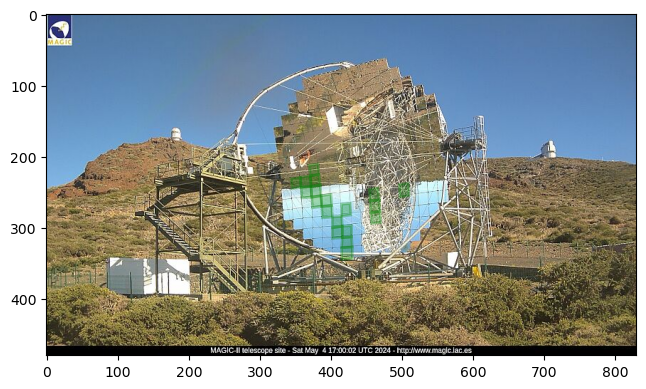

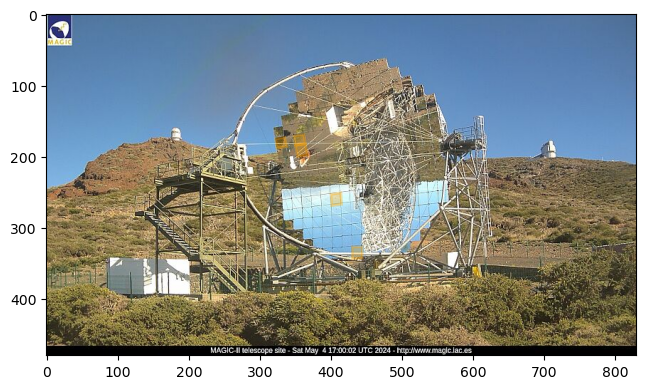

In [22]:
mark_mirrors_on_img(img_path_3, ground_truth_list, "green")
mark_mirrors_on_img(img_path_3, p_list, "orange")


In [11]:
new_features.shape

(249, 11)

In [25]:
# 3. Liczymy odległość — score per lustro
scores_maha = distance_mahalanobis(new_features, baseline)

In [26]:
scores_maha.shape

(249,)

Łącznie luster: 249
Lustro 50 -> sąsiedzi: [0, 2, 10, 11]


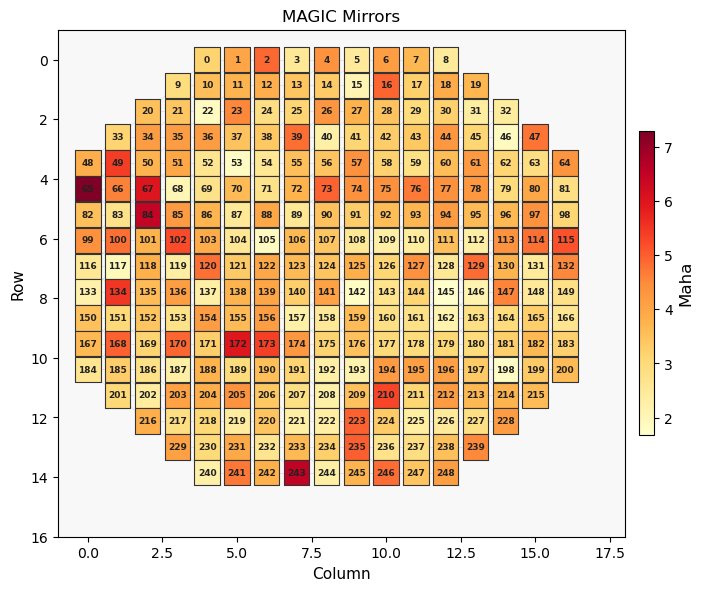

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
visualization_mirrors(scores_maha, "Maha", ax)

(array([ 1.,  6.,  1.,  2.,  4., 11.,  8., 11.,  7.,  6., 12.,  9.,  8.,
        15., 10., 13., 14., 16., 13.,  8.,  8.,  5., 14.,  8.,  7.,  4.,
         3.,  4.,  5.,  5.,  1.,  1.,  2.,  1.,  1.,  0.,  0.,  0.,  2.,
         0.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([1.67374044, 1.7860563 , 1.89837217, 2.01068804, 2.1230039 ,
        2.23531977, 2.34763564, 2.4599515 , 2.57226737, 2.68458324,
        2.7968991 , 2.90921497, 3.02153084, 3.13384671, 3.24616257,
        3.35847844, 3.47079431, 3.58311017, 3.69542604, 3.80774191,
        3.92005777, 4.03237364, 4.14468951, 4.25700537, 4.36932124,
        4.48163711, 4.59395298, 4.70626884, 4.81858471, 4.93090058,
        5.04321644, 5.15553231, 5.26784818, 5.38016404, 5.49247991,
        5.60479578, 5.71711164, 5.82942751, 5.94174338, 6.05405925,
        6.16637511, 6.27869098, 6.39100685, 6.50332271, 6.61563858,
        6.72795445, 6.84027031, 6.95258618, 7.06490205, 7.17721791,
        7.28953378]),
 <BarContainer

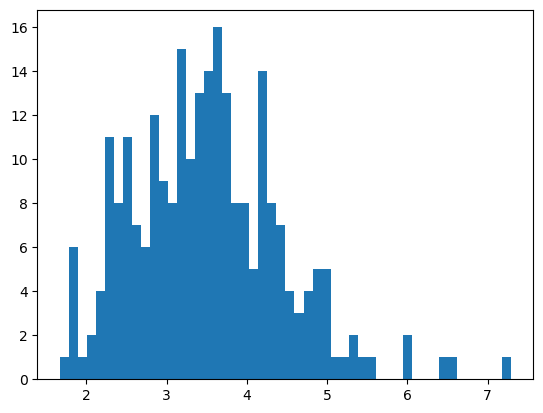

In [29]:
plt.hist(scores_maha, bins=50)